In [45]:
import os
import tempfile
import subprocess

import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.style.use('seaborn-v0_8-whitegrid')

In [46]:
ROOTRACKER_FILE = '/home/hep/jcc525/comet_data/midstream_merged00000001.rootracker'
TREE_NAME = 'RooTrackerTree'
PDG_CODE = 13
MONITOR_ID = 4

GEOMETRY_FILE = '/vols/comet/data/phaseIgeom.root'
GEOMETRY_KEY = 'COMETGeometry-991d653d-29fe3ca5-487c39de-61ad2e64-d67e8aca'

OUTPUT_DIR = '/home/hep/jcc525/gan_particle_physics/gan_results/geometry_checks'
os.makedirs(OUTPUT_DIR, exist_ok=True)

with uproot.open(ROOTRACKER_FILE) as f:
    tree = f[TREE_NAME]
    arrays = tree.arrays(['StdHepPdg', 'StdHepX4', 'MonitorID'], library='ak')

pdg = ak.flatten(arrays['StdHepPdg'])
x4 = ak.flatten(arrays['StdHepX4'])
monitor_id = ak.flatten(arrays['MonitorID'])

pdg_np = ak.to_numpy(pdg)
mid_np = ak.to_numpy(monitor_id)

print(f'Tree: {TREE_NAME} | events: {tree.num_entries:,}')

# All monitors (all particles)
mid_values, mid_counts = np.unique(mid_np, return_counts=True)
print('MonitorID counts (all particles):', {int(k): int(v) for k, v in zip(mid_values, mid_counts)})

# All monitors / all PDG IDs excluding photons
non_photon = pdg_np != 22
mid_nonph = mid_np[non_photon]
pdg_nonph = pdg_np[non_photon]

print('\nNon-photon totals:')
print(f'  particles: {len(pdg_nonph):,}')
print('  MonitorID counts:', {int(k): int(v) for k, v in zip(*np.unique(mid_nonph, return_counts=True))})

pdg_values, pdg_counts = np.unique(pdg_nonph, return_counts=True)
order = np.argsort(-pdg_counts)
print('\nPDG counts (non-photon, sorted):')
for k, v in zip(pdg_values[order], pdg_counts[order]):
    print(f'  PDG {int(k):>6d}: {int(v):,}')

print('\nMonitorID × PDG counts (non-photon):')
for mid in np.unique(mid_nonph):
    m = mid_nonph == mid
    pvals, pcounts = np.unique(pdg_nonph[m], return_counts=True)
    porder = np.argsort(-pcounts)
    parts = ', '.join([f'{int(pvals[i])}:{int(pcounts[i])}' for i in porder])
    print(f'  MonitorID {int(mid)} -> {parts}')

# Keep focused subset for the centering comparisons below
mask = (pdg == PDG_CODE) & (monitor_id == MONITOR_ID)
x4_sel = x4[mask]

x_raw = ak.to_numpy(x4_sel[:, 0])
y_raw = ak.to_numpy(x4_sel[:, 1])
z_raw = ak.to_numpy(x4_sel[:, 2])

x0_raw, y0_raw, z0_raw = float(np.mean(x_raw)), float(np.mean(y_raw)), float(np.mean(z_raw))
print(f'\nRaw RooTrackerTree origin (x0, y0, z0) [mm] for PDG={PDG_CODE}, MonitorID={MONITOR_ID}: ({x0_raw:.3f}, {y0_raw:.3f}, {z0_raw:.3f})')
print(f'Selected entries (PDG={PDG_CODE}, MonitorID={MONITOR_ID}): {len(x_raw):,}')

Tree: RooTrackerTree | events: 1,000,000
MonitorID counts (all particles): {1: 24, 2: 628, 3: 5, 4: 49828}

Non-photon totals:
  particles: 21,587
  MonitorID counts: {1: 9, 2: 370, 3: 1, 4: 21207}

PDG counts (non-photon, sorted):
  PDG   2112: 7,680
  PDG     11: 7,584
  PDG     13: 4,737
  PDG    -11: 1,221
  PDG   -211: 330
  PDG    -13: 27
  PDG   2212: 8

MonitorID × PDG counts (non-photon):
  MonitorID 1 -> 2112:7, -11:1, 11:1
  MonitorID 2 -> 2112:365, 11:5
  MonitorID 3 -> 2112:1
  MonitorID 4 -> 11:7578, 2112:7307, 13:4737, -11:1220, -211:330, -13:27, 2212:8

Raw RooTrackerTree origin (x0, y0, z0) [mm] for PDG=13, MonitorID=4: (3258.960, -12.710, 7655.529)
Selected entries (PDG=13, MonitorID=4): 4,737


In [47]:
macro = '''
void read_positions() {{
    TFile *f = TFile::Open("{geometry_file}");
    TGeoManager *g = (TGeoManager*)f->Get("{geometry_key}");

    const char* names[] = {{"WORLD", "DET_SOL", "CDC"}};
    const char* paths[] = {{
        "/comet_1",
        "/comet_1/DetectorSolenoid_0",
        "/comet_1/DetectorSolenoid_0/CylindricalDetector_0"
    }};

    for (int i = 0; i < 3; ++i) {{
        if (g->cd(paths[i])) {{
            const Double_t *t = g->GetCurrentMatrix()->GetTranslation();
            printf("GEOM:%s:%.6f:%.6f:%.6f\\n", names[i], t[0], t[1], t[2]);
        }}
    }}

    // Attempt target path variants
    const char* target_paths[] = {{
        "/comet_1/MuonStoppingTargetSystem_0",
        "/comet_1/DetectorSolenoid_0/MuonStoppingTargetSystem_0",
        "/comet_1/MuonStoppingTarget_0"
    }};
    for (int j = 0; j < 3; ++j) {{
        if (g->cd(target_paths[j])) {{
            const Double_t *t = g->GetCurrentMatrix()->GetTranslation();
            printf("GEOM:TARGET:%.6f:%.6f:%.6f\\n", t[0], t[1], t[2]);
            break;
        }}
    }}
}}
'''.format(geometry_file=GEOMETRY_FILE, geometry_key=GEOMETRY_KEY)

with tempfile.NamedTemporaryFile(mode='w', suffix='.C', delete=False) as tmp:
    macro_path = tmp.name
    func_name = os.path.splitext(os.path.basename(macro_path))[0]
    tmp.write(macro.replace('read_positions', func_name))

result = subprocess.run(
    ['root', '-l', '-b', '-q', f'{macro_path}()'],
    capture_output=True,
    text=True,
    timeout=180,
    check=False,
)
os.remove(macro_path)

geom_vals = {}
for line in result.stdout.splitlines():
    if line.startswith('GEOM:'):
        _, name, sx, sy, sz = line.split(':')
        geom_vals[name] = (float(sx), float(sy), float(sz))

x0_world, y0_world, z0_world = geom_vals['WORLD']
x0_det, y0_det, z0_det = geom_vals['DET_SOL']
x0_cdc, y0_cdc, z0_cdc = geom_vals['CDC']
x0_target, y0_target, z0_target = geom_vals.get('TARGET', (717.5, 0.0, 765.0))

x0_mid, y0_mid, z0_mid = 3259.0, 0.0, z0_raw

print('Geometry file values [mm]:')
print(f'  WORLD           : ({x0_world:.3f}, {y0_world:.3f}, {z0_world:.3f})')
print(f'  DET_SOL         : ({x0_det:.3f}, {y0_det:.3f}, {z0_det:.3f})')
print(f'  CDC             : ({x0_cdc:.3f}, {y0_cdc:.3f}, {z0_cdc:.3f})')
print(f'  PARTICLE_TARGET : ({x0_target:.3f}, {y0_target:.3f}, {z0_target:.3f})')
print(f'  MIDSTREAM (data): ({x0_mid:.3f}, {y0_mid:.3f}, {z0_mid:.3f})')

Geometry file values [mm]:
  WORLD           : (0.000, 0.000, 0.000)
  DET_SOL         : (654.090, 0.000, 765.000)
  CDC             : (673.995, 0.000, 765.000)
  PARTICLE_TARGET : (717.500, 0.000, 765.000)
  MIDSTREAM (data): (3259.000, 0.000, 7655.529)


In [48]:
# Centering schemes
x_mean_centered = x_raw - x0_raw
y_mean_centered = y_raw - y0_raw
z_mean_centered = z_raw - z0_raw

x_cdc_centered = x_raw - x0_cdc
y_cdc_centered = y_raw - y0_cdc
z_cdc_centered = z_raw - z0_cdc

x_mid_centered = x_raw - x0_mid
y_mid_centered = y_raw - y0_mid
z_mid_centered = z_raw - z0_mid

print('Delta values (raw origin - reference) [mm]:')
print(f'  vs CDC             : ({x0_raw-x0_cdc:+.3f}, {y0_raw-y0_cdc:+.3f}, {z0_raw-z0_cdc:+.3f})')
print(f'  vs PARTICLE_TARGET : ({x0_raw-x0_target:+.3f}, {y0_raw-y0_target:+.3f}, {z0_raw-z0_target:+.3f})')
print(f'  vs MIDSTREAM       : ({x0_raw-x0_mid:+.3f}, {y0_raw-y0_mid:+.3f}, {z0_raw-z0_mid:+.3f})')

Delta values (raw origin - reference) [mm]:
  vs CDC             : (+2584.965, -12.710, +6890.529)
  vs PARTICLE_TARGET : (+2541.460, -12.710, +6890.529)
  vs MIDSTREAM       : (-0.040, -12.710, +0.000)


Saved: /home/hep/jcc525/gan_particle_physics/gan_results/geometry_checks/distribution_comparison_raw_mean_geom.png


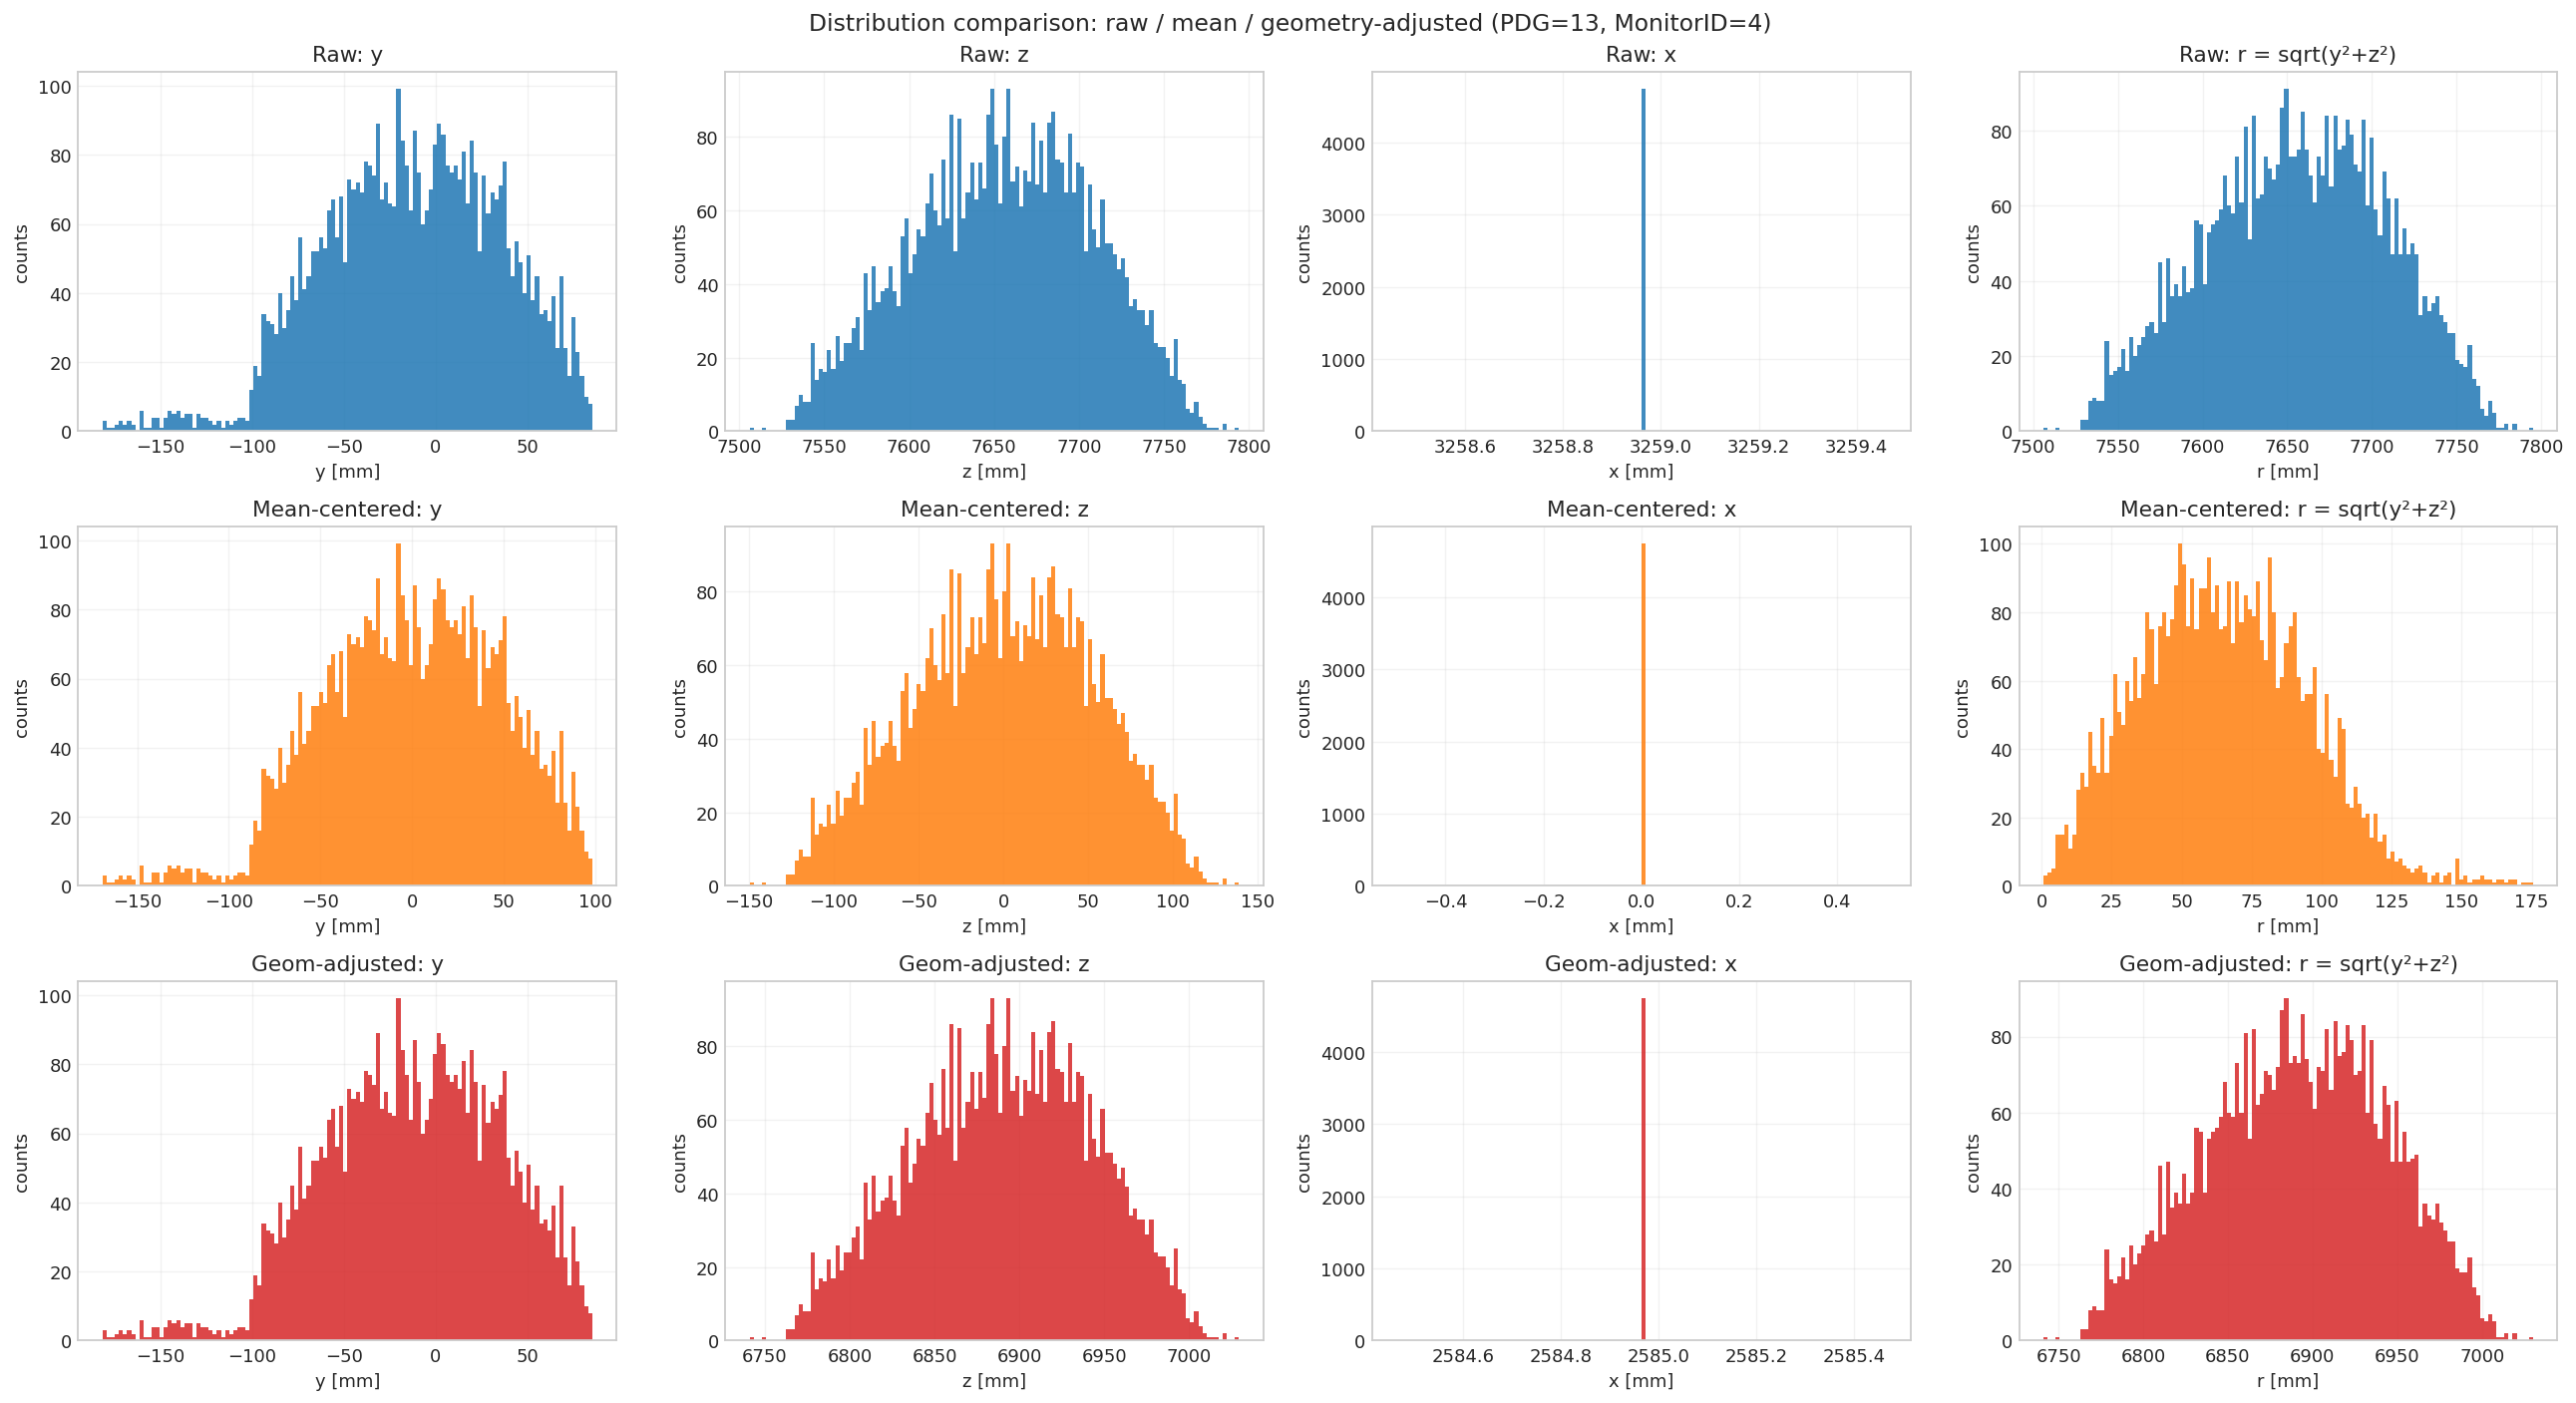

In [51]:
# Distribution comparison: raw vs mean vs geometry-adjusted
raw_r = np.sqrt(y_raw**2 + z_raw**2)
mean_r = np.sqrt(y_mean_centered**2 + z_mean_centered**2)
geom_r = np.sqrt(y_cdc_centered**2 + z_cdc_centered**2)

dist_sets = [
    ('Raw', x_raw, y_raw, z_raw, raw_r, 'tab:blue'),
    ('Mean-centered', x_mean_centered, y_mean_centered, z_mean_centered, mean_r, 'tab:orange'),
    ('Geom-adjusted', x_cdc_centered, y_cdc_centered, z_cdc_centered, geom_r, 'tab:red'),
]

figd, axd = plt.subplots(3, 4, figsize=(20, 11), dpi=130)
for row, (label, xv, yv, zv, rv, col) in enumerate(dist_sets):
    axd[row, 0].hist(yv, bins=120, color=col, alpha=0.85)
    axd[row, 0].set_title(f'{label}: y')
    axd[row, 0].set_xlabel('y [mm]')

    axd[row, 1].hist(zv, bins=120, color=col, alpha=0.85)
    axd[row, 1].set_title(f'{label}: z')
    axd[row, 1].set_xlabel('z [mm]')

    axd[row, 2].hist(xv, bins=120, color=col, alpha=0.85)
    axd[row, 2].set_title(f'{label}: x')
    axd[row, 2].set_xlabel('x [mm]')

    axd[row, 3].hist(rv, bins=120, color=col, alpha=0.85)
    axd[row, 3].set_title(f'{label}: r = sqrt(y²+z²)')
    axd[row, 3].set_xlabel('r [mm]')

    for c in range(4):
        axd[row, c].set_ylabel('counts')
        axd[row, c].grid(alpha=0.25)

figd.suptitle(f'Distribution comparison: raw / mean / geometry-adjusted (PDG={PDG_CODE}, MonitorID={MONITOR_ID})', fontsize=13)
plt.tight_layout()

out_dist = os.path.join(OUTPUT_DIR, 'distribution_comparison_raw_mean_geom.png')
figd.savefig(out_dist, dpi=150)
print('Saved:', out_dist)
plt.show()

Saved: /home/hep/jcc525/gan_particle_physics/gan_results/geometry_checks/coordinate_centering_comparison.png


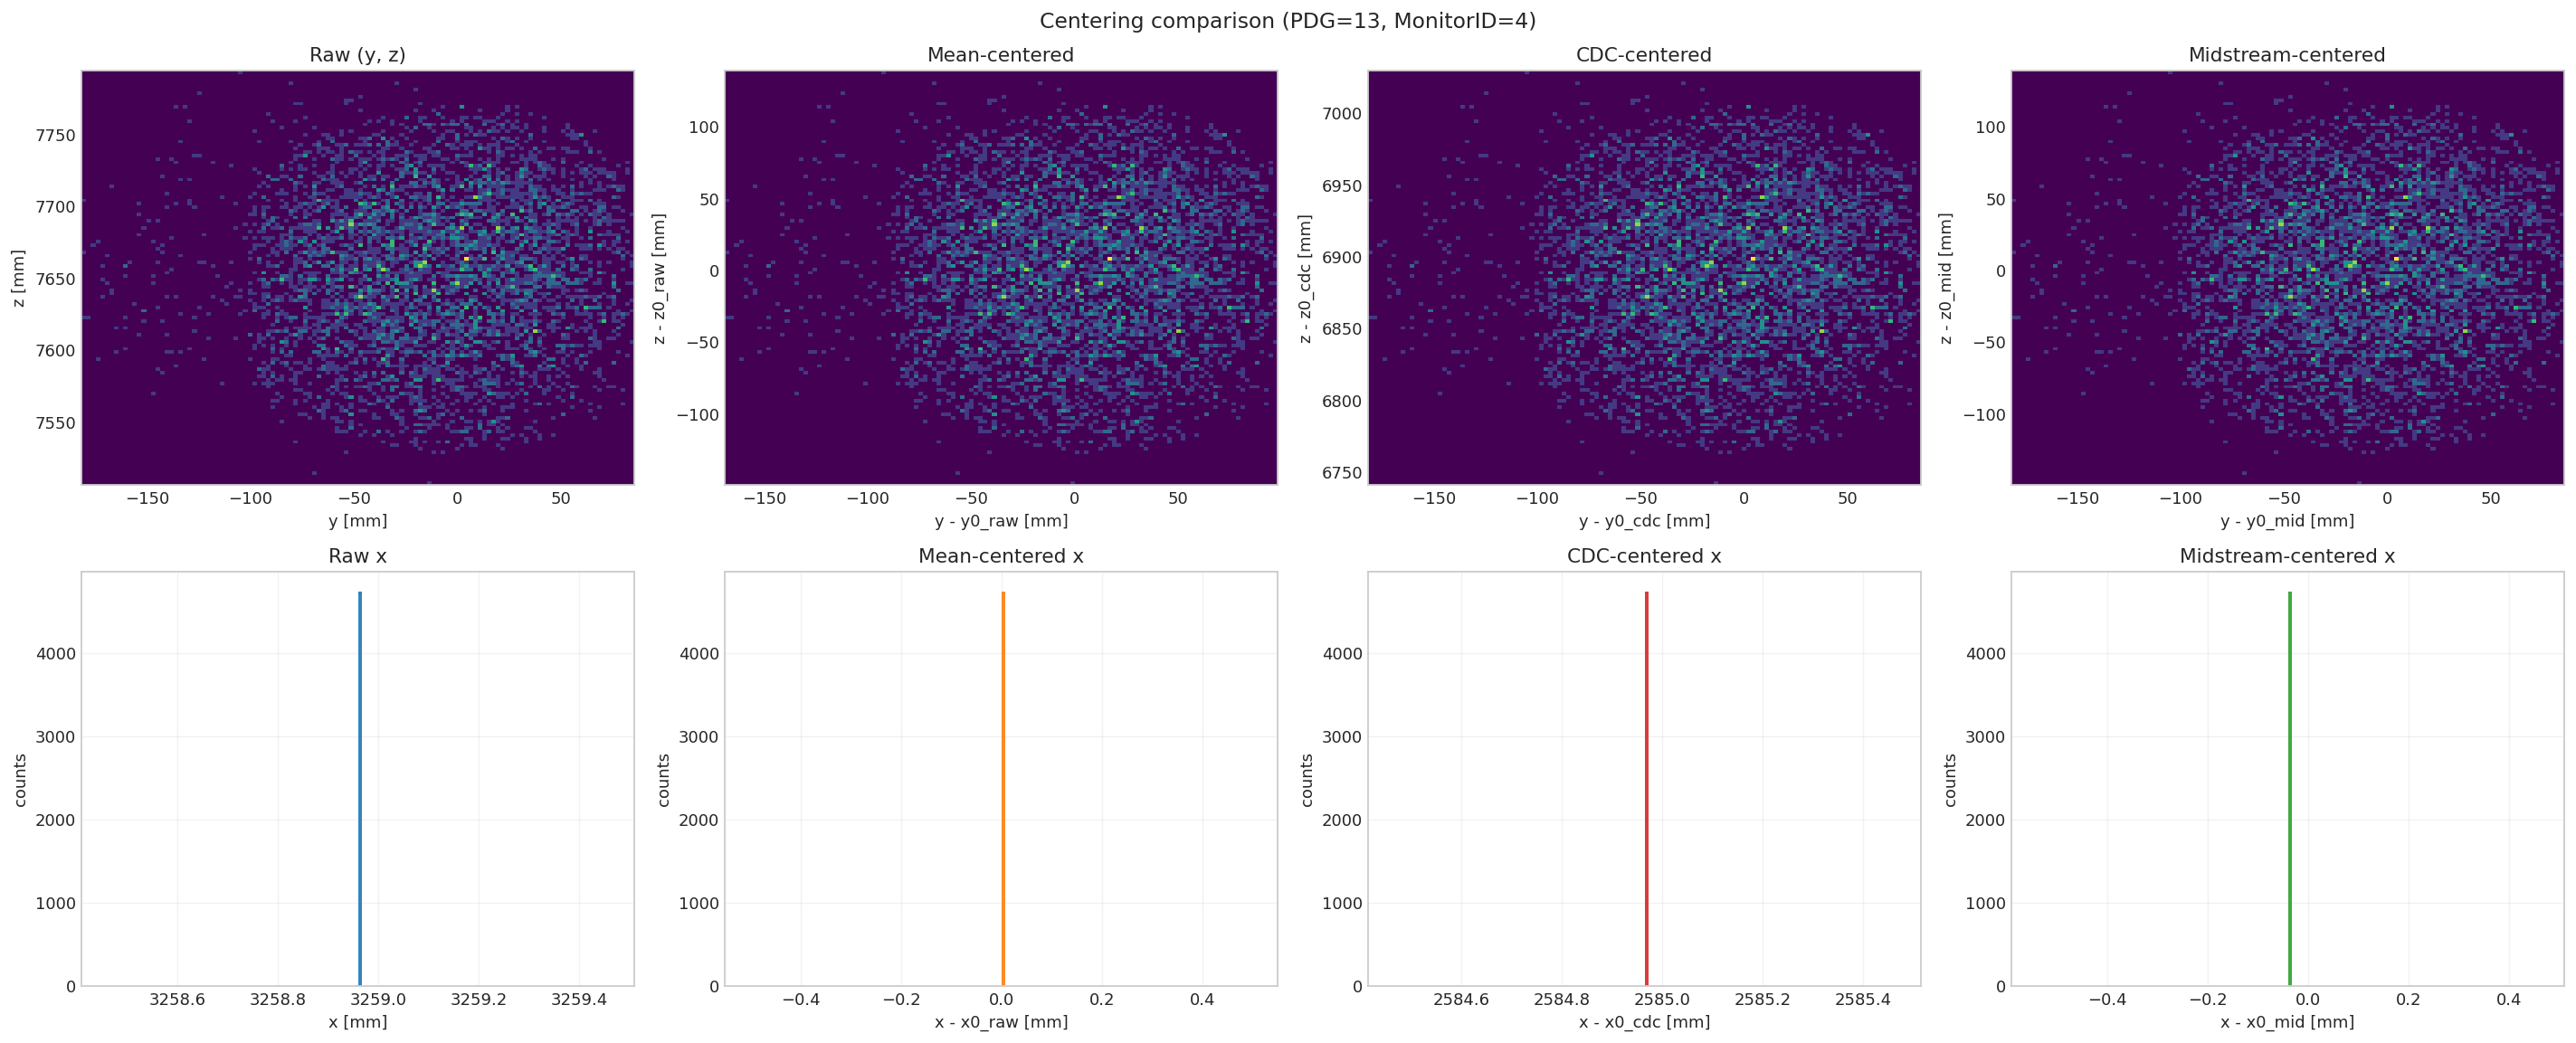

In [49]:
sample_size = min(120000, len(x_raw))
rng = np.random.default_rng(42)
idx = rng.choice(len(x_raw), size=sample_size, replace=False) if sample_size < len(x_raw) else np.arange(len(x_raw))

fig, axes = plt.subplots(2, 4, figsize=(22, 9), dpi=130)

# Y-Z comparisons
axes[0, 0].hist2d(y_raw[idx], z_raw[idx], bins=120, cmap='viridis')
axes[0, 0].set_title('Raw (y, z)')
axes[0, 0].set_xlabel('y [mm]'); axes[0, 0].set_ylabel('z [mm]')

axes[0, 1].hist2d(y_mean_centered[idx], z_mean_centered[idx], bins=120, cmap='viridis')
axes[0, 1].set_title('Mean-centered')
axes[0, 1].set_xlabel('y - y0_raw [mm]'); axes[0, 1].set_ylabel('z - z0_raw [mm]')

axes[0, 2].hist2d(y_cdc_centered[idx], z_cdc_centered[idx], bins=120, cmap='viridis')
axes[0, 2].set_title('CDC-centered')
axes[0, 2].set_xlabel('y - y0_cdc [mm]'); axes[0, 2].set_ylabel('z - z0_cdc [mm]')

axes[0, 3].hist2d(y_mid_centered[idx], z_mid_centered[idx], bins=120, cmap='viridis')
axes[0, 3].set_title('Midstream-centered')
axes[0, 3].set_xlabel('y - y0_mid [mm]'); axes[0, 3].set_ylabel('z - z0_mid [mm]')

# X comparisons
axes[1, 0].hist(x_raw, bins=120, color='tab:blue', alpha=0.9)
axes[1, 0].set_title('Raw x')
axes[1, 0].set_xlabel('x [mm]'); axes[1, 0].set_ylabel('counts')

axes[1, 1].hist(x_mean_centered, bins=120, color='tab:orange', alpha=0.9)
axes[1, 1].set_title('Mean-centered x')
axes[1, 1].set_xlabel('x - x0_raw [mm]'); axes[1, 1].set_ylabel('counts')

axes[1, 2].hist(x_cdc_centered, bins=120, color='tab:red', alpha=0.9)
axes[1, 2].set_title('CDC-centered x')
axes[1, 2].set_xlabel('x - x0_cdc [mm]'); axes[1, 2].set_ylabel('counts')

axes[1, 3].hist(x_mid_centered, bins=120, color='tab:green', alpha=0.9)
axes[1, 3].set_title('Midstream-centered x')
axes[1, 3].set_xlabel('x - x0_mid [mm]'); axes[1, 3].set_ylabel('counts')

for ax in axes.ravel():
    ax.grid(alpha=0.25)

fig.suptitle(f'Centering comparison (PDG={PDG_CODE}, MonitorID={MONITOR_ID})', fontsize=13)
plt.tight_layout()

out_png = os.path.join(OUTPUT_DIR, 'coordinate_centering_comparison.png')
fig.savefig(out_png, dpi=150)
print('Saved:', out_png)
plt.show()

Saved: /home/hep/jcc525/gan_particle_physics/gan_results/geometry_checks/3d_scatter_centering_comparison.png


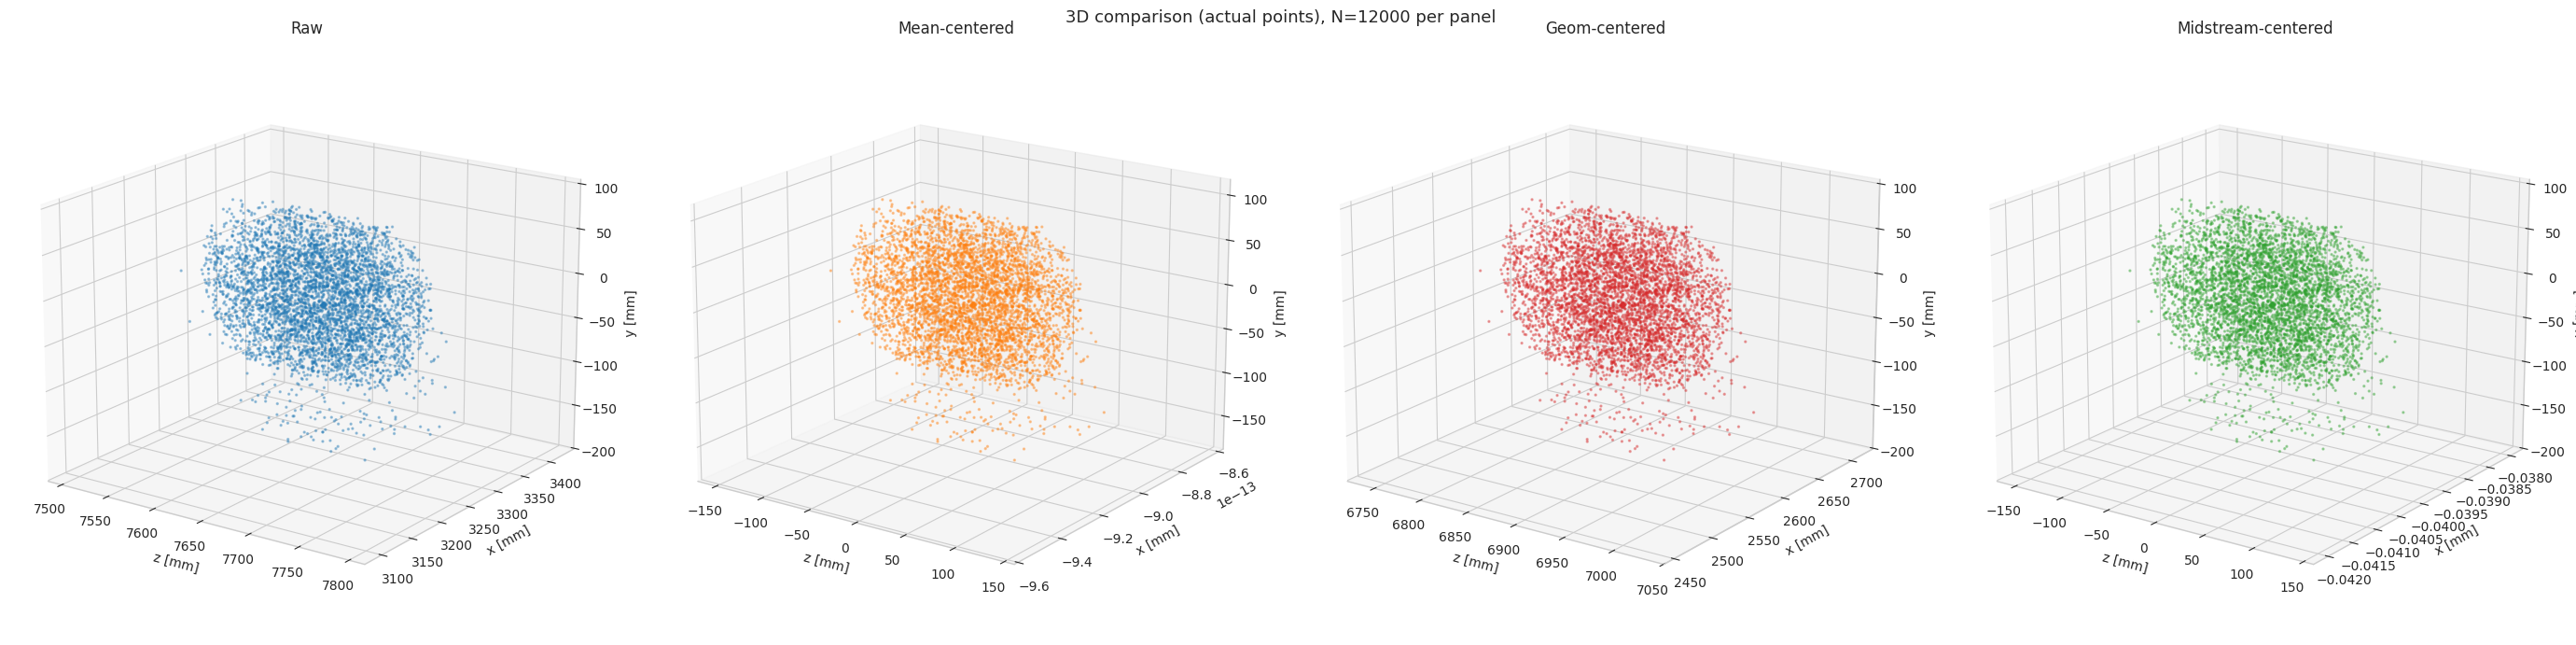

In [52]:
MAX_SCATTER = 12000
rng3d = np.random.default_rng(7)

def sample_triplet(x_arr, y_arr, z_arr, n):
    take = min(n, len(x_arr))
    idx = rng3d.choice(len(x_arr), size=take, replace=False)
    return x_arr[idx], y_arr[idx], z_arr[idx]

schemes = [
    ('Raw', x_raw, y_raw, z_raw, 'tab:blue'),
    ('Mean-centered', x_mean_centered, y_mean_centered, z_mean_centered, 'tab:orange'),
    ('Geom-centered', x_cdc_centered, y_cdc_centered, z_cdc_centered, 'tab:red'),
    ('Midstream-centered', x_mid_centered, y_mid_centered, z_mid_centered, 'tab:green'),
]

fig3d, axes3d = plt.subplots(1, 4, figsize=(28, 7), subplot_kw={'projection': '3d'})
fig3d.suptitle(f'3D comparison (actual points), N={MAX_SCATTER} per panel', fontsize=13)

for ax, (label, xs, ys, zs, color) in zip(axes3d, schemes):
    xs_s, ys_s, zs_s = sample_triplet(xs, ys, zs, MAX_SCATTER)

    ax.scatter(zs_s, xs_s, ys_s, c=color, s=2, alpha=0.35)
    ax.set_title(label)
    ax.set_xlabel('z [mm]')
    ax.set_ylabel('x [mm]')
    ax.set_zlabel('y [mm]')
    ax.view_init(elev=18, azim=-55)

plt.tight_layout()
out_3d = os.path.join(OUTPUT_DIR, '3d_scatter_centering_comparison.png')
fig3d.savefig(out_3d, dpi=140, bbox_inches='tight')
print('Saved:', out_3d)
plt.show()